Notebook designed to test SWOT-frames quality filtering process.

***

__author__ = "Miguel González Jiménez, migj" <br>
__maintainer__ = "Miguel González Jiménez, migj"<br>
__email__ = "mgonzalez.j@gmv.com"

***

In [1]:
import rioxarray as riox
from pathlib import Path
import pandas as pd
import geopandas as gpd

import SWOT as swot

from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [2]:
path_series = r"../data/HF_VIIRS_non-Safe_series.parquet"
path_hfs    = r"..data/HF_non-Safe_metadata.geojson"
swot.VIIRS.set_paths(path_series=path_series, path_hfs=path_hfs)

### Reading frames

In [ ]:
indir = Path(r"path_to_downloaded_SWOT_frames")
Files = swot.Reader(indir, remove_duplicates=True, clipToHF=True, _limit=50)

Reading SWOT frames:   0%|          | 0/45 [00:00<?, ?it/s]

Clipping frames to those containig HFs:   0%|          | 0/45 [00:00<?, ?it/s]

Contains_HF
True     33
False    12
Name: count, dtype: int64


### Getting Flood Depth (from geoid)


In [ ]:
Scene = Files.df.object.iloc[12]
Scene.dem = Path(r"path_to_DEM_referenced_respect_EGM2008_geoid_EPSG4326.tif")

In [ ]:
Scene.filtrate_qual(0,1)\
     .filtrate_cross(10000,60000)\
     .filtrate_water(0.15)\
     .filtrate_dark(0.2)\
     .filtrate_uncert(0.5)\
     .filtrate_layover(95)\
     .filtr_bitwise('geolocation_qual_degraded',
                    'classification_qual_degraded',
                    'value_bad')

<Axes: >

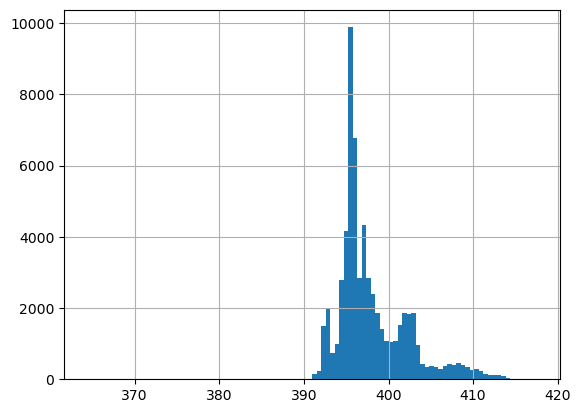

In [ ]:
# Getting distribution of WSE values within frame
Scene.da.wse.to_dataframe().wse.dropna().hist(bins=100)

### Getting Flood Depth (from ground) using Hydro-conditioned MERIT DEM 
Former approach

In [ ]:
Scene = Files.df.object.iloc[12]
Scene.dem = Path(r"path_to_DEM_referenced_respect_EGM2008_geoid_EPSG4326.tif")

In [31]:
Scene.filtrate_qual(0,1).filtrate_cross(10000,60000)\
                               .filtrate_water(0.15)\
                               .filtrate_dark(0.2)\
                               .filtrate_uncert(0.5)\
                               .filtrate_layover(95)\
                               .filtr_bitwise('geolocation_qual_degraded',
                                        'classification_qual_degraded',
                                        'value_bad').toDepth(gt=0, lt=15)

array([<Axes: title={'center': 'Not-Filtered'}, xlabel='x coordinate of projection [m]', ylabel='y coordinate of projection [m]'>,
       <Axes: title={'center': 'Filtered'}, xlabel='x coordinate of projection [m]', ylabel='y coordinate of projection [m]'>],
      dtype=object)

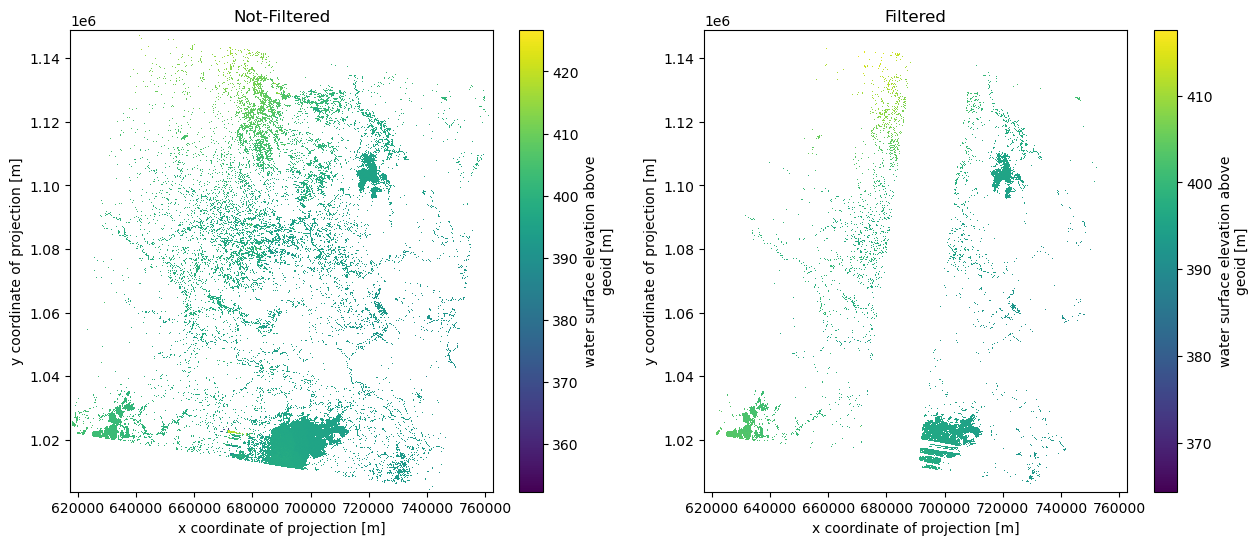

In [27]:
Scene.filtr_plot()

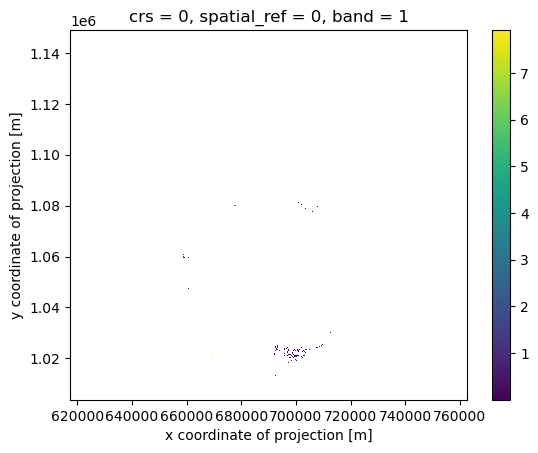

In [29]:
Scene.depth.plot()

### Example of Flood Descriptors Extraction from HF patches availble within SWOT footprint

Plotting patches and points of specific frame

<Axes: >

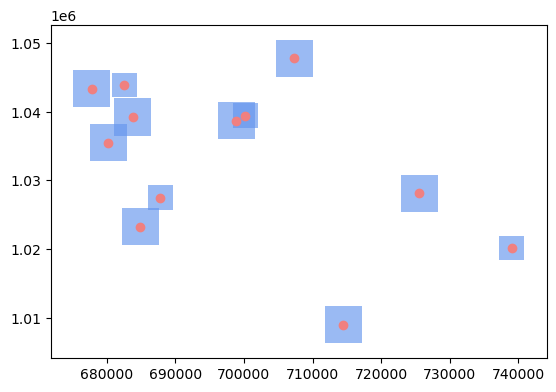

In [55]:
ax = Scene.stats.points.plot(zorder=6, color='lightcoral')
Scene.stats.patches.plot(ax=ax, color='cornflowerblue', alpha=0.65)

Getting flood descriptors of specific patch

In [60]:
random_patch = Scene.stats.get_patches('geoid')[5] # 'geoid' or 'ground' according to flood depth reference desired

Getting descriptors from a random patch

In [62]:
random_patch.stats

,hf_id,longitude,latitude,hf_payam,buffer_pixels,ID,zona_nombre,patch_size,index_right,name,...,shortname,geometry,IsFlooded,FloodFraction,Mean,Median,Max,Distance,DateTime,SwotFile
150,manajoga phcu,28.811239,9.392128,SS060101,60,003,CHRONIC,5400,0,SWOT_x_043_277_086F_20251223T101453_using-MERI...,...,SWOT_L2_HR_Raster_100m_UTM35P_20251223,POINT (698893.055 1038718.374),True,0.024348,395.06,394.55,396.43,547.841725,2025-12-23 10:14:53.862174+00:00,SWOT_L2_HR_Raster_100m_UTM35P_20251223
